In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# DATA LOADING

In [2]:
import warnings
# To ignore all warnings
warnings.filterwarnings("ignore")

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
from skimage.feature import hog
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



In [4]:
# Function to load the image files
def load_images(file_path):
    with open(file_path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows * cols)
    return images

# Function to load the label files
def load_labels(file_path):
    with open(file_path, 'rb') as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

# Loading training data
train_images = load_images('/content/drive/MyDrive/Fashion_PJ_AI/DataSet_Fashion-MNIST/train-images-idx3-ubyte')
train_labels = load_labels('/content/drive/MyDrive/Fashion_PJ_AI/DataSet_Fashion-MNIST/train-labels-idx1-ubyte')

# Loading testing data
test_images = load_images('/content/drive/MyDrive/Fashion_PJ_AI/DataSet_Fashion-MNIST/t10k-images-idx3-ubyte')
test_labels = load_labels('/content/drive/MyDrive/Fashion_PJ_AI/DataSet_Fashion-MNIST/t10k-labels-idx1-ubyte')

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


# PREPROCESSING

In [7]:
# Split training data into training and validation sets (80% training, 20% validation)
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

print("Training set size:", len(train_images))
print("Validation set size:", len(val_images))


Training set size: 48000
Validation set size: 12000


In [8]:
# Nomalize data, scale to range between 0 and 1
scaler = MinMaxScaler()
train_images_scaled = scaler.fit_transform(train_images)
val_images_scaled = scaler.transform(val_images)
test_images_scaled = scaler.transform(test_images)


In [9]:
train_images_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [10]:
# Drop and Rotation if possible and necessary...
# Define data augmentation
data_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(28)
])

### Perform basic exploratory data analysis (EDA) to understand the distribution of classes and visualize some sample images.

In [5]:
def showOneImage(row, df=train_images, colors="gray"):
    plt.imshow(df[row].reshape(28, 28), cmap=colors)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# Function to display multiple images of a given label
def showLabel(label, df=train_images, labels=train_labels, n=50):
    labelselect = df[labels == label]
    plt.figure(figsize=(10, 5), dpi=150)
    for i in range(min(n, len(labelselect))):
        plt.subplot(n // 10, 10, i + 1)
        image_data = labelselect[i].reshape(28, 28)
        plt.imshow(image_data, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()

'label 0'

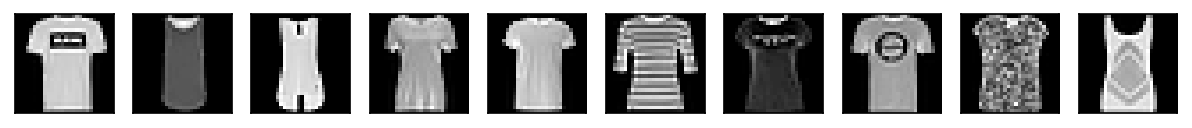

'label 1'

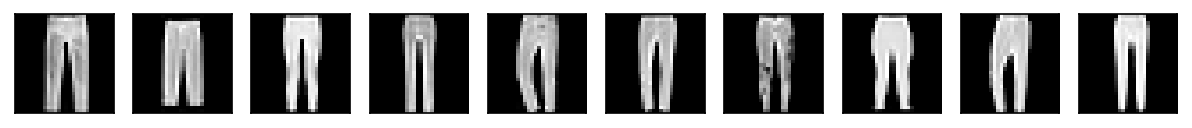

'label 2'

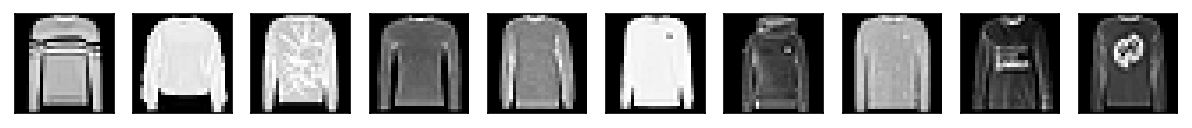

'label 3'

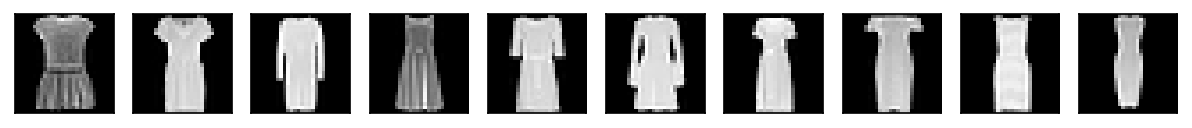

'label 4'

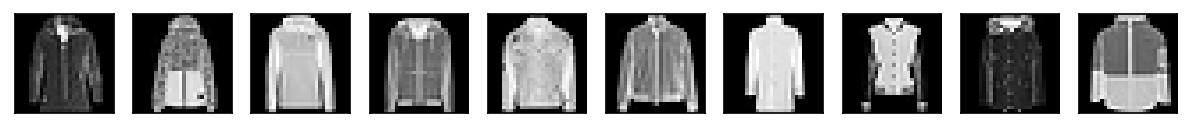

'label 5'

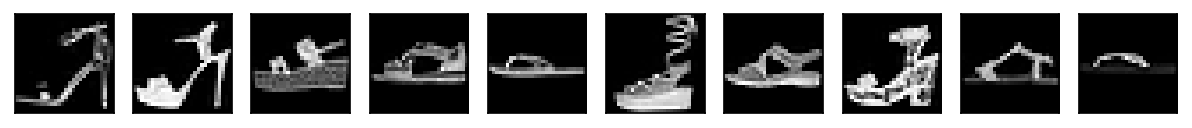

'label 6'

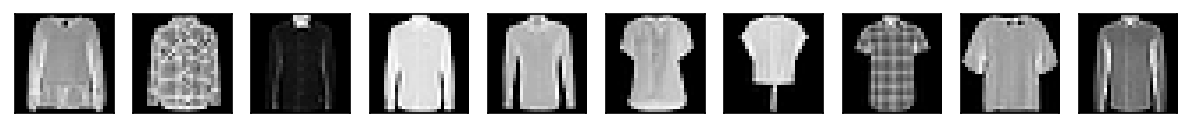

'label 7'

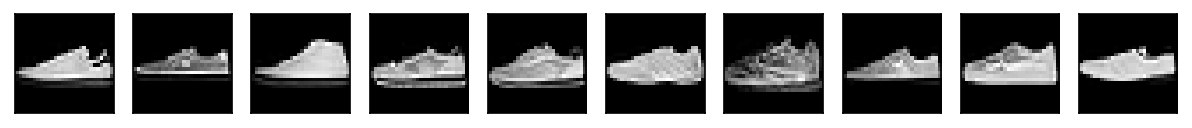

'label 8'

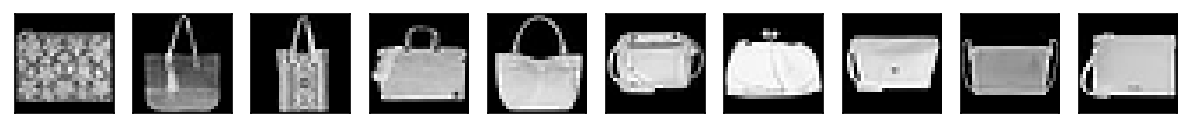

'label 9'

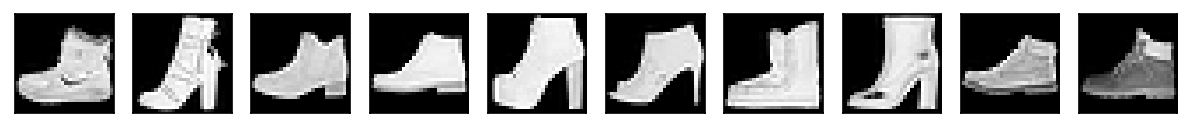

In [6]:
for label in range(10):
    display(f"label {label}")
    showLabel(label, n=10)

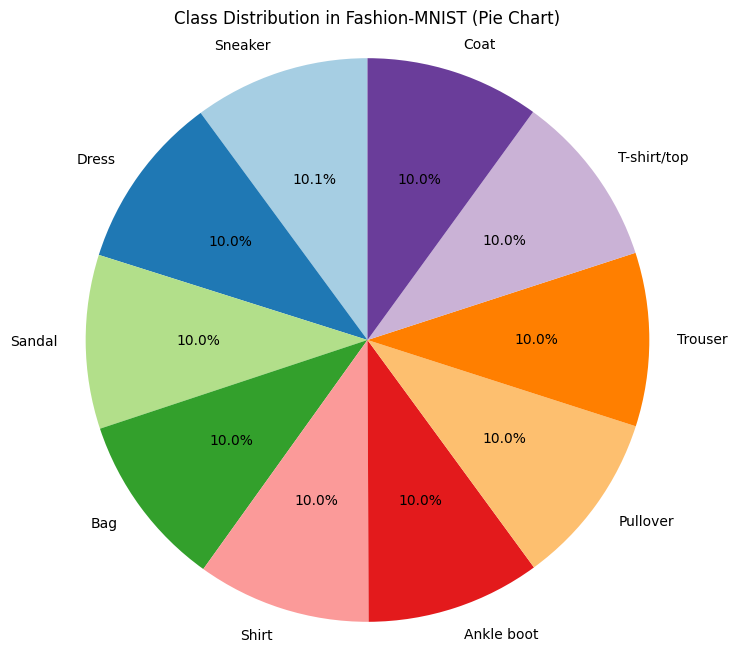

In [11]:
# List of class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def pie_chart_class_distribution(labels):
    class_counts = Counter(labels)
    counts = list(class_counts.values())
    classes = [class_names[i] for i in class_counts.keys()]

    plt.figure(figsize=(8, 8))
    plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title('Class Distribution in Fashion-MNIST (Pie Chart)')
    plt.axis('equal')
    plt.show()

# Distribution of train_lables
pie_chart_class_distribution(train_labels)

The number of each layer is the same => the dataset is balanced

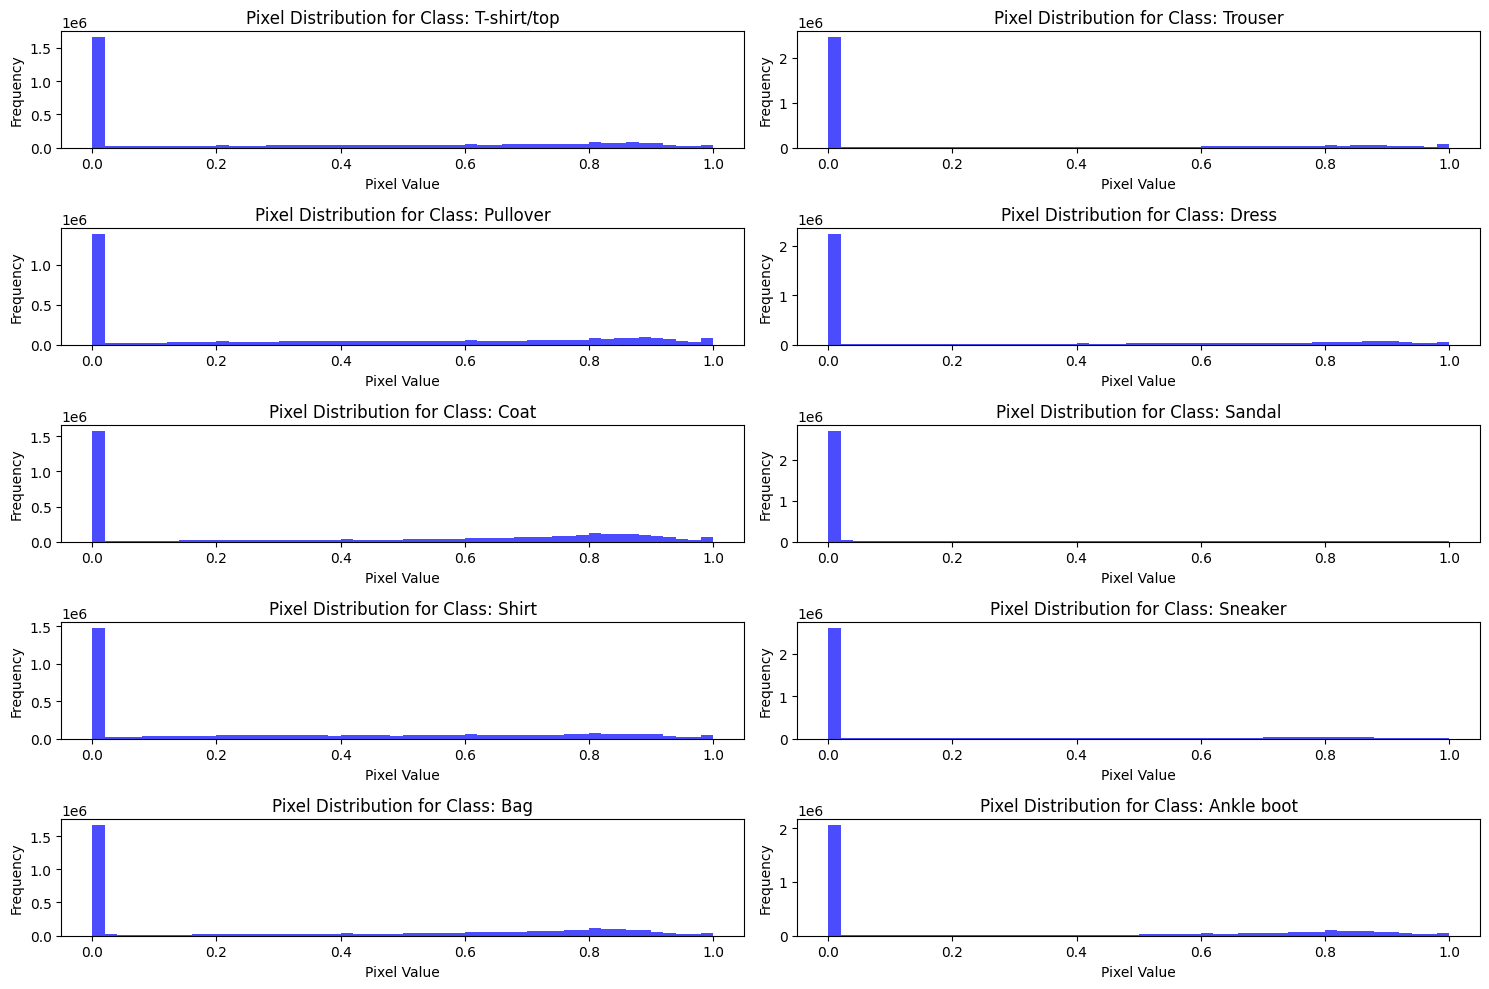

In [12]:
# Visualize distibution of each class
def plot_pixel_distribution_by_class(images, labels, class_names):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_flat, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]}')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_by_class(train_images_scaled, train_labels, class_names)


We can see values .0 that are too dominant. So I adjust excluded_value to filter out other dominant pixel values such as 0 (representing black or background pixels) and plot again.

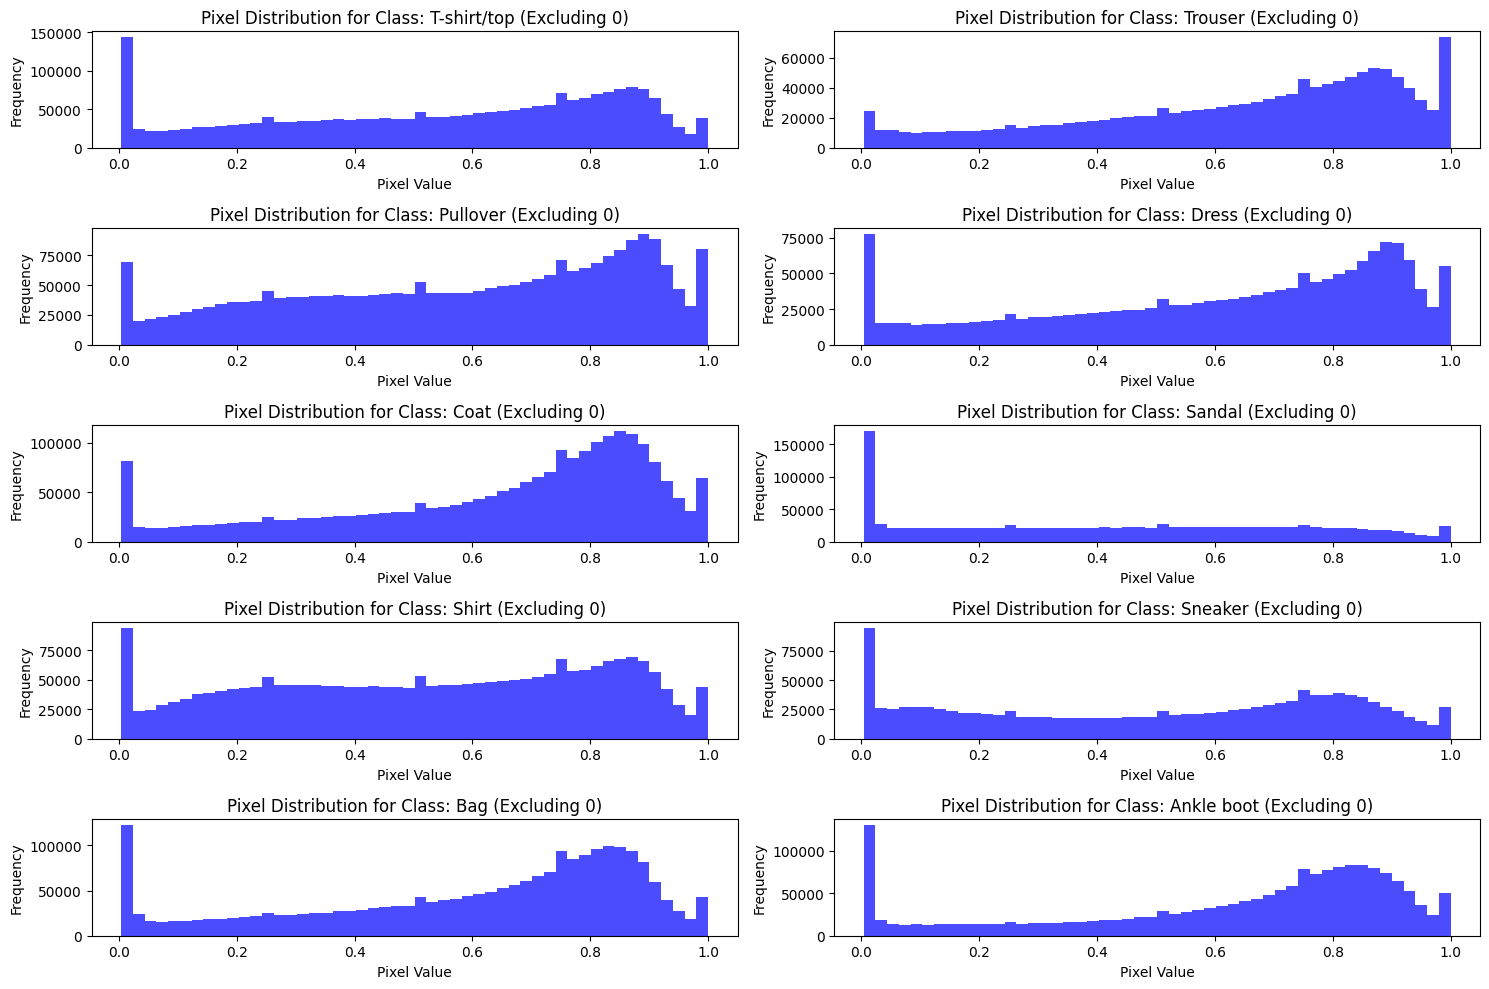

In [13]:
# Function to plot pixel intensity distribution for each class excluding certain pixel values
def plot_pixel_distribution_excluding_values(images, labels, class_names, excluded_value=0):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        # Exclude pixels with the given value (e.g., 0)
        class_images_filtered = class_images_flat[class_images_flat != excluded_value]

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_filtered, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]} (Excluding {excluded_value})')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_excluding_values(train_images_scaled, train_labels, class_names)

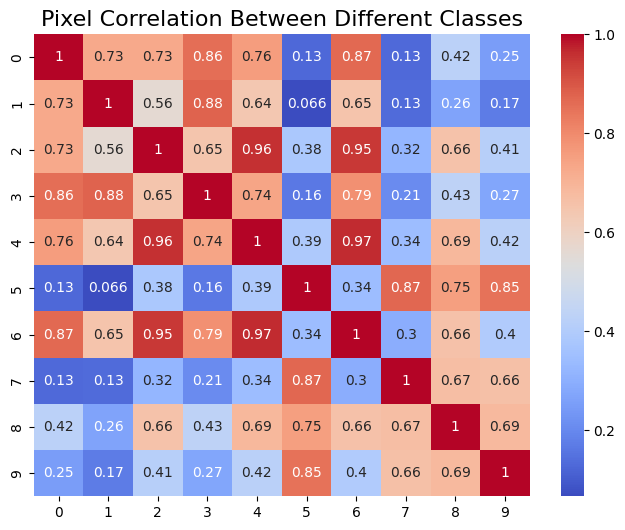

In [14]:
# Built correlation matrix

# Calculate the correlation matrix between classes
class_images = {label: [] for label in np.unique(train_labels)}
for i, label in enumerate(train_labels):
    class_images[label].append(train_images[i])

# Calculate the average image of each layer
mean_images = {label: np.mean(images, axis=0) for label, images in class_images.items()}

# Calculate the correlation matrix between classes
correlation_matrix = np.corrcoef([mean_image.flatten() for mean_image in mean_images.values()])

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=np.unique(train_labels), yticklabels=np.unique(train_labels))
plt.title("Pixel Correlation Between Different Classes", fontsize=16)
plt.show()

The correlation coefficient of some classes is quite large => easily causes confusion, and reduces the performance of the model, especially logistic regression because the way this model operates is closely related to the correlation of the data of the classes.

In [16]:
# HoG pretreatment with cell size of [4 4] (according to IJITEE research paper by Greeshma K V and Sreekumar K)
"""
It is clearly understood that the cell size [2 2] contains
more shape information than the cell size of [8 8] in their
visualization. But in the latter case the dimensionality of
feature vector using HOG increases comparing with the
former. A good choice is the [4 4] cell size.

We can apply with cell size [2 2] or [8 8] to check
"""
# demo with cell size of [4 4]
def apply_hog(images):
    hog_features = []
    for image in images:
        image_reshaped = image.reshape(28, 28)
        hog_feature = hog(image_reshaped, pixels_per_cell=(4, 4), cells_per_block=(2, 2), visualize=False)
        hog_features.append(hog_feature)
    return np.array(hog_features)

train_hog = apply_hog(train_images_scaled)
val_hog = apply_hog(val_images_scaled)
test_hog = apply_hog(test_images_scaled)

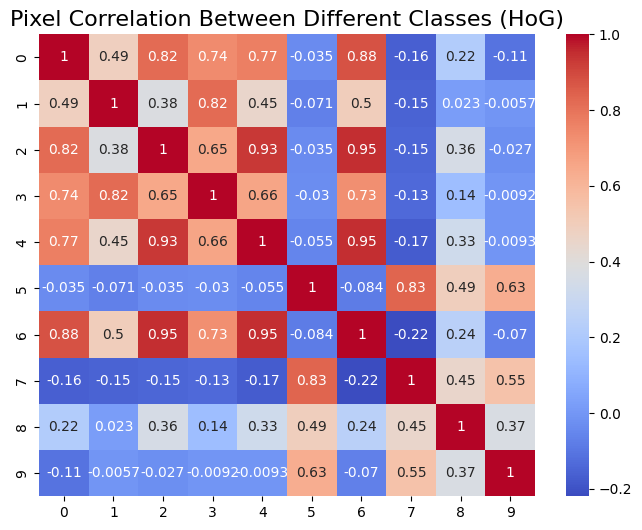

In [17]:
# Compute the inter-class correlation matrix as before
class_images = {label: [] for label in np.unique(train_labels)}
for i, label in enumerate(train_labels):
    class_images[label].append(train_hog[i])

mean_images = {label: np.mean(images, axis=0) for label, images in class_images.items()}
correlation_matrix = np.corrcoef([mean_image.flatten() for mean_image in mean_images.values()])


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=np.unique(train_labels), yticklabels=np.unique(train_labels))
plt.title("Pixel Correlation Between Different Classes (HoG)", fontsize=16)
plt.show()

The changes in correlation reflect that HoG preprocessing effectively captures texture and edge features. Lower or negative correlations show that HoG might be helping to differentiate between some classes that have similar pixel intensities but different structures.

=> We'll build the model and perform to clearly see the impact

## Demo Logistic Regression

### LR basic with method OvR using train_images_scaled

In [21]:
model = LogisticRegression(multi_class='ovr', solver='saga', max_iter=100, random_state=42)

# Train the model
model.fit(train_images_scaled, train_labels)

# Predict on test data
test_predictions = model.predict(test_images_scaled)

In [22]:
accuracy = accuracy_score(test_labels, test_predictions)
precision = precision_score(test_labels, test_predictions, average='macro')
recall = recall_score(test_labels, test_predictions, average='macro')
f1 = f1_score(test_labels, test_predictions, average='macro')

In [24]:
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.8423
Precision: 0.8400731155504688
Recall: 0.8423
F1 Score: 0.8405050317554899


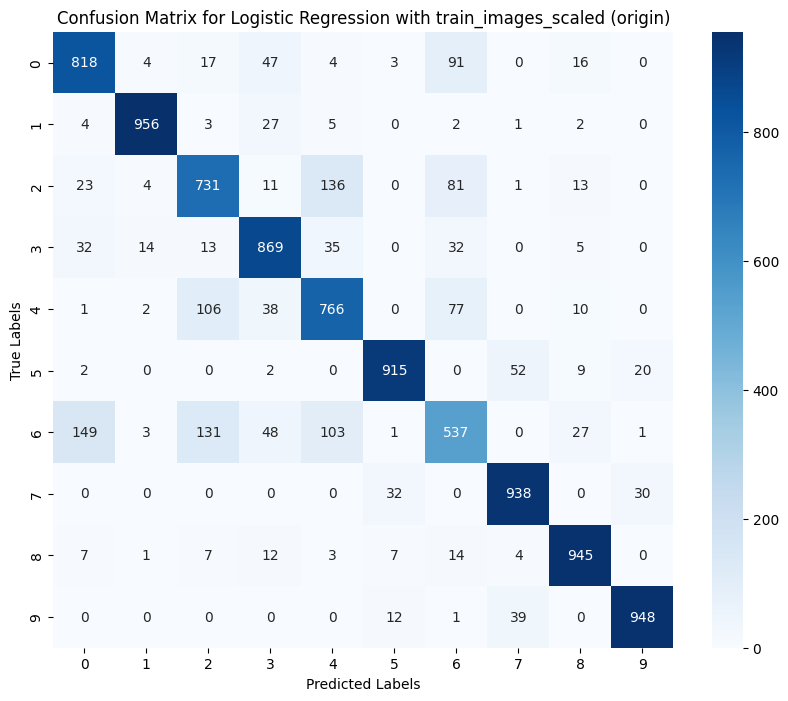

In [33]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Logistic Regression with train_images_scaled (origin)')
plt.show()

### LR basic with method OvR using train_hog (using Hog preprocessing to reduce pixel correlation coefficient)

In [ ]:
model_hog = LogisticRegression(multi_class='ovr', solver='saga', max_iter=100, random_state=42)

# Train the model
model_hog.fit(train_hog, train_labels)

In [26]:
# predict
test_predictions_hog = model_hog.predict(test_hog)

In [27]:
accuracy_hog = accuracy_score(test_labels, test_predictions_hog)
precision_hog = precision_score(test_labels, test_predictions_hog, average='macro')
recall_hog = recall_score(test_labels, test_predictions_hog, average='macro')
f1_hog = f1_score(test_labels, test_predictions_hog, average='macro')

In [28]:
print(f"Accuracy: {accuracy_hog}")
print(f"Precision: {precision_hog}")
print(f"Recall: {recall_hog}")
print(f"F1 Score: {f1_hog}")

Accuracy: 0.8871
Precision: 0.8859686300282632
Recall: 0.8871
F1 Score: 0.8862565583591892


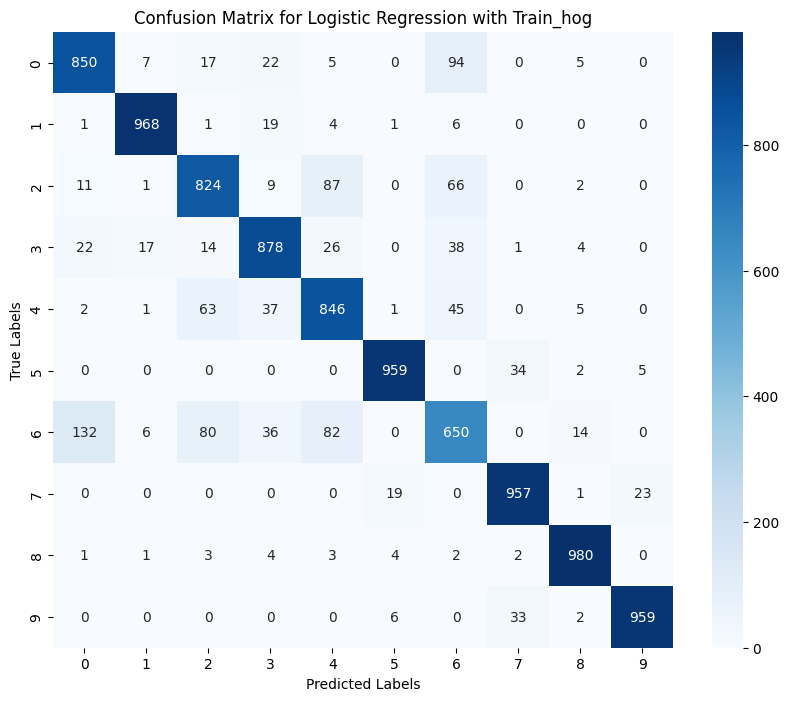

In [34]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels, test_predictions_hog)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Logistic Regression with Train_hog')
plt.show()

When using Hog Preprocessing to reduce the correlation coefficient, the Model will be significantly more effective